EXPERIMENT 6
MONTE CARLO PREDICTION AND CONTROL

10 SAMPLE DATASET RECORDS


,State,Action,Reward,Gamma
0,8,0,-5.00,0.954
1,6,1,0.47,0.850
2,7,0,3.74,0.926
3,5,1,1.80,0.895
4,5,0,-0.70,0.921
5,8,0,2.08,0.908
6,9,1,0.37,0.885
7,5,1,-2.69,0.850
8,8,1,2.57,0.918
9,7,0,-0.45,0.898


Total Records: 500


,min,max,mean,std
State,0.00,9.00,4.302,2.746
Action,0.00,1.00,0.462,0.499
Reward,-5.00,10.00,2.611,4.346
Gamma,0.85,0.99,0.923,0.038



DOWNLOAD DATASET:


...

<IPython.core.display.Javascript object>


MONTE CARLO STATE VALUES


,State,MC_Value,Best_Control_Value,Best_Action
0,0,-7.438,-1.980,0
1,1,-6.358,-0.975,0
2,2,-4.987,0.073,0
3,3,-2.982,1.275,0
4,4,-0.438,2.520,0
5,5,2.299,4.138,0
6,6,5.323,5.711,0
7,7,8.000,7.339,0
8,8,10.000,10.000,0
9,9,0.000,0.000,0



SUMMARY RESULTS


,Metric,Result
0,Dataset Records,500.000
1,Episodes,500.000
2,States,10.000
3,Actions,2.000
4,Gamma,0.900
5,Alpha,0.100
6,Epsilon,0.100
7,Average MC Value,0.342
8,Maximum MC Value,10.000
9,Average Control Reward,0.652


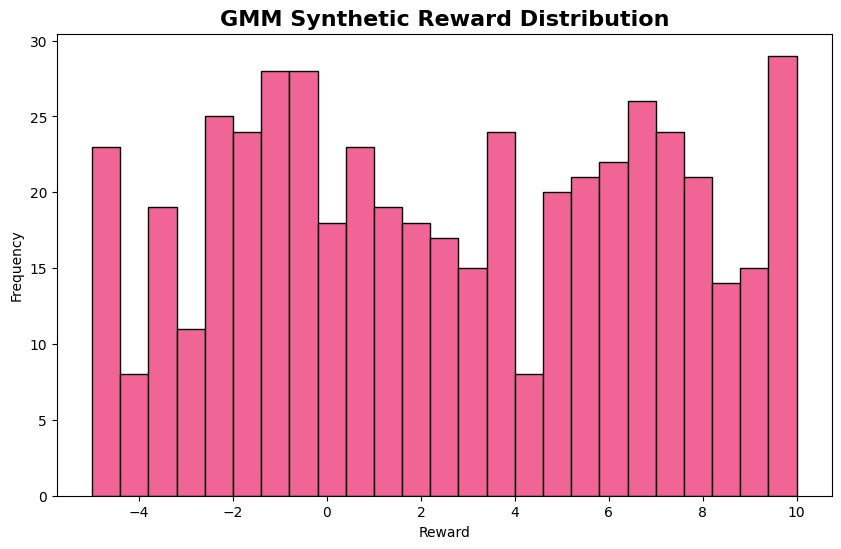

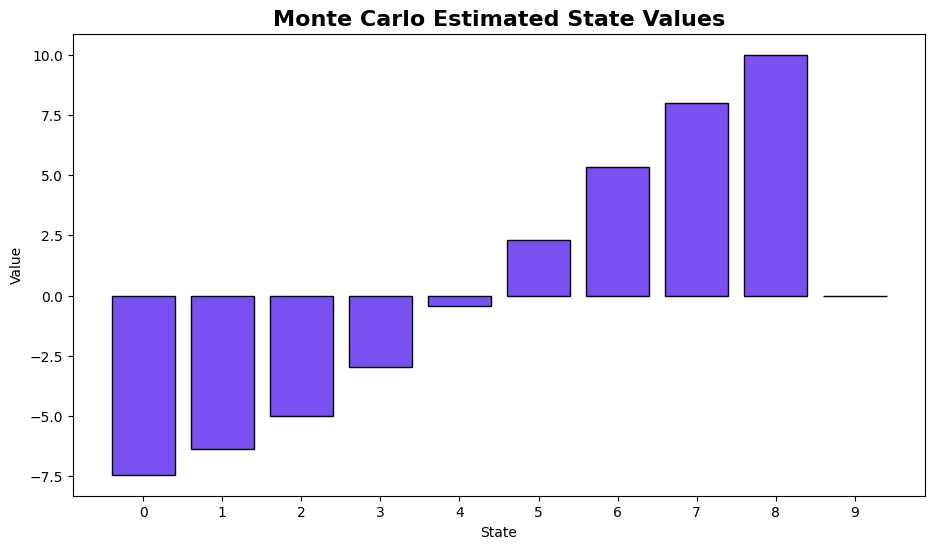

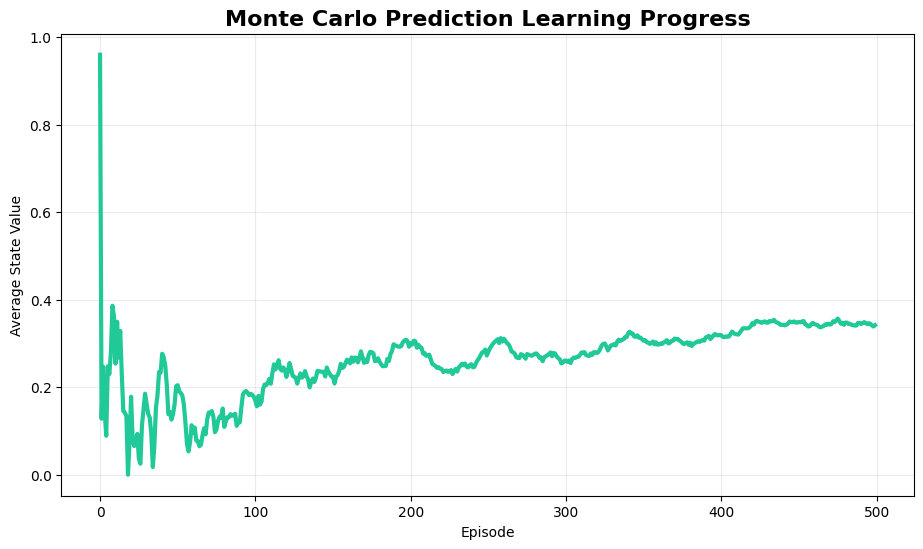

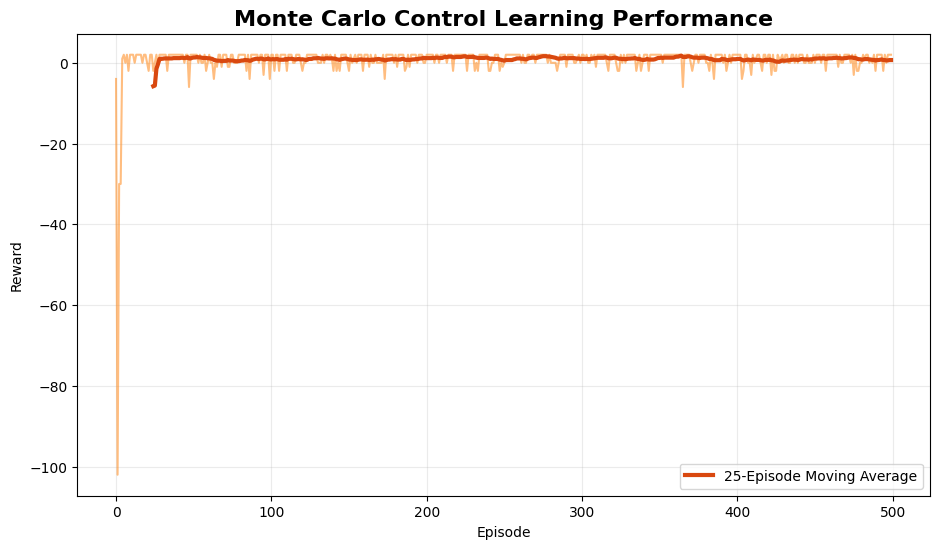

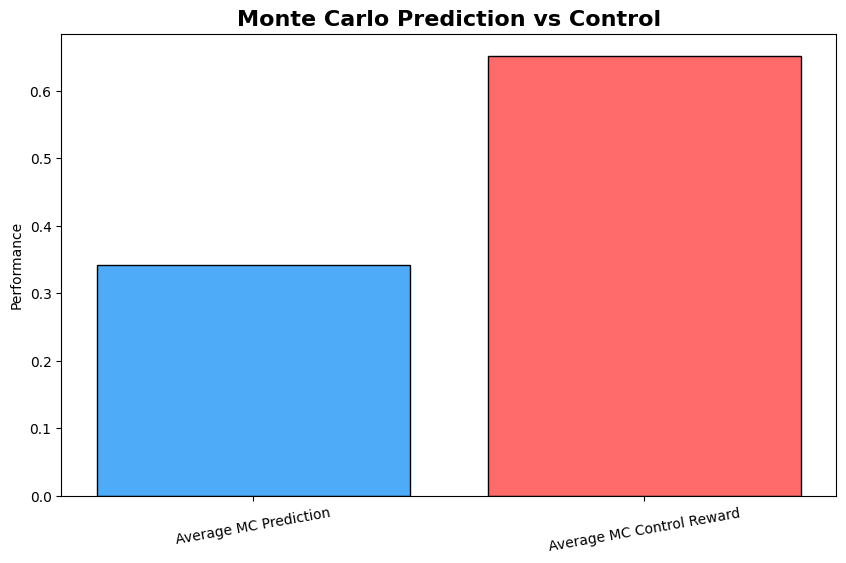


Experiment 6 completed successfully.


In [ ]:
# ==============================================================
# EXPERIMENT 6
# MONTE CARLO PREDICTION AND CONTROL
# FOR REINFORCEMENT LEARNING
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from IPython.display import display, FileLink
from google.colab import files

np.random.seed(42)

print("=" * 80)
print("EXPERIMENT 6")
print("MONTE CARLO PREDICTION AND CONTROL")
print("=" * 80)

# ==============================================================
# 1. GMM DATASET
# ==============================================================

N = 500

base = np.column_stack([
    np.random.randint(0, 10, N),
    np.random.randint(0, 2, N),
    np.random.uniform(-5, 10, N),
    np.random.uniform(0.85, 0.99, N)
])

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(base)

generated = gmm.sample(N)[0]

dataset = pd.DataFrame(
    generated,
    columns=[
        "State",
        "Action",
        "Reward",
        "Gamma"
    ]
)

dataset["State"] = dataset["State"].clip(0, 9).round().astype(int)
dataset["Action"] = dataset["Action"].clip(0, 1).round().astype(int)
dataset["Reward"] = dataset["Reward"].clip(-5, 10).round(2)
dataset["Gamma"] = dataset["Gamma"].clip(0.85, 0.99).round(3)

# ==============================================================
# 2. SAMPLE DATA
# ==============================================================

print("\n10 SAMPLE DATASET RECORDS")

display(dataset.head(10))

print("Total Records:", len(dataset))

# ==============================================================
# 3. SUMMARY
# ==============================================================

display(
    dataset.describe().T[
        ["min", "max", "mean", "std"]
    ].round(3)
)

# ==============================================================
# 4. DOWNLOAD
# ==============================================================

filename = "Experiment_6_Monte_Carlo_GMM_Dataset.csv"

dataset.to_csv(
    filename,
    index=False
)

print("\nDOWNLOAD DATASET:")

display(FileLink(filename))

files.download(filename)

# ==============================================================
# 5. ENVIRONMENT
# ==============================================================

N_STATES = 10
N_ACTIONS = 2

EPISODES = 500
GAMMA = 0.90
ALPHA = 0.10
EPSILON = 0.10

# ==============================================================
# 6. EPISODE
# ==============================================================

def generate_episode():

    state = 0
    episode = []

    while state != 9:

        action = np.random.randint(
            N_ACTIONS
        )

        if action == 0:
            next_state = min(
                state + 1,
                9
            )
        else:
            next_state = max(
                state - 1,
                0
            )

        reward = (
            10
            if next_state == 9
            else -1
        )

        episode.append(
            (state, action, reward)
        )

        state = next_state

    return episode

# ==============================================================
# 7. MONTE CARLO PREDICTION
# ==============================================================

V_mc = np.zeros(N_STATES)

returns_sum = np.zeros(N_STATES)
returns_count = np.zeros(N_STATES)

prediction_history = []

for episode in range(EPISODES):

    ep = generate_episode()

    G = 0
    visited = set()

    for state, action, reward in reversed(ep):

        G = reward + GAMMA * G

        if state not in visited:

            returns_sum[state] += G
            returns_count[state] += 1

            V_mc[state] = (
                returns_sum[state]
                /
                returns_count[state]
            )

            visited.add(state)

    prediction_history.append(
        np.mean(V_mc)
    )

# ==============================================================
# 8. MONTE CARLO CONTROL
# ==============================================================

Q = np.zeros(
    (N_STATES, N_ACTIONS)
)

control_rewards = []

for episode in range(EPISODES):

    state = 0
    ep = []

    while state != 9:

        if np.random.rand() < EPSILON:
            action = np.random.randint(
                N_ACTIONS
            )
        else:
            action = np.argmax(
                Q[state]
            )

        if action == 0:
            next_state = min(
                state + 1,
                9
            )
        else:
            next_state = max(
                state - 1,
                0
            )

        reward = (
            10
            if next_state == 9
            else -1
        )

        ep.append(
            (state, action, reward)
        )

        state = next_state

    G = 0

    for s, a, r in reversed(ep):

        G = r + GAMMA * G

        Q[s, a] += (
            ALPHA *
            (G - Q[s, a])
        )

    control_rewards.append(
        sum(x[2] for x in ep)
    )

# ==============================================================
# 9. RESULT TABLE
# ==============================================================

state_values = pd.DataFrame({
    "State": range(N_STATES),
    "MC_Value": V_mc,
    "Best_Control_Value": np.max(Q, axis=1),
    "Best_Action": np.argmax(Q, axis=1)
}).round(3)

print("\nMONTE CARLO STATE VALUES")

display(state_values)

# ==============================================================
# 10. SUMMARY
# ==============================================================

summary = pd.DataFrame({
    "Metric": [
        "Dataset Records",
        "Episodes",
        "States",
        "Actions",
        "Gamma",
        "Alpha",
        "Epsilon",
        "Average MC Value",
        "Maximum MC Value",
        "Average Control Reward",
        "Maximum Control Reward"
    ],

    "Result": [
        len(dataset),
        EPISODES,
        N_STATES,
        N_ACTIONS,
        GAMMA,
        ALPHA,
        EPSILON,
        round(np.mean(V_mc), 3),
        round(np.max(V_mc), 3),
        round(np.mean(control_rewards), 3),
        max(control_rewards)
    ]
})

print("\nSUMMARY RESULTS")

display(summary)

# ==============================================================
# 11. VISUALIZATION 1
# DATASET REWARD
# ==============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    dataset["Reward"],
    bins=25,
    color="#f06595",
    edgecolor="black"
)

plt.title(
    "GMM Synthetic Reward Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Reward")
plt.ylabel("Frequency")

plt.show()

# ==============================================================
# 12. VISUALIZATION 2
# MC VALUE
# ==============================================================

plt.figure(figsize=(11, 6))

plt.bar(
    range(N_STATES),
    V_mc,
    color="#7950f2",
    edgecolor="black"
)

plt.title(
    "Monte Carlo Estimated State Values",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Value")

plt.xticks(range(N_STATES))

plt.show()

# ==============================================================
# 13. VISUALIZATION 3
# PREDICTION LEARNING
# ==============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    prediction_history,
    color="#20c997",
    linewidth=3
)

plt.title(
    "Monte Carlo Prediction Learning Progress",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Average State Value")

plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 14. VISUALIZATION 4
# CONTROL REWARDS
# ==============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    control_rewards,
    color="#ff922b",
    alpha=0.6
)

moving_average = pd.Series(
    control_rewards
).rolling(25).mean()

plt.plot(
    moving_average,
    color="#d9480f",
    linewidth=3,
    label="25-Episode Moving Average"
)

plt.title(
    "Monte Carlo Control Learning Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Episode")
plt.ylabel("Reward")

plt.legend()
plt.grid(alpha=0.25)

plt.show()

# ==============================================================
# 15. VISUALIZATION 5
# PREDICTION VS CONTROL
# ==============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    [
        "Average MC Prediction",
        "Average MC Control Reward"
    ],
    [
        np.mean(V_mc),
        np.mean(control_rewards)
    ],
    color=["#4dabf7", "#ff6b6b"],
    edgecolor="black"
)

plt.title(
    "Monte Carlo Prediction vs Control",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Performance")

plt.xticks(rotation=10)

plt.show()

print("\nExperiment 6 completed successfully.")